<a href="https://colab.research.google.com/github/yaesur/business_python/blob/main/%EB%AF%B8%EA%B5%AD_AI_%EC%8B%9C%EC%9E%A5%EA%B3%BC_%ED%95%9C%EA%B5%AD_%EC%84%B1%EC%9E%A5%EC%A3%BC_%EC%8B%9C%EC%9E%A5%EC%9D%98_%EB%8F%99%EC%A1%B0%ED%99%94_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2024 한 해

/tmp/ipykernel_5986/3917596557.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  2 of 2 completed

               NVIDIA      KOSDAQ
Date                             
2024-01-02  48.138569  878.929993
2024-01-03  47.539932  871.570007
2024-01-04  47.968678  866.250000
2024-01-05  49.067001  878.330017
2024-01-08  52.221073  879.340027

일간 수익률
              NVIDIA    KOSDAQ
Date                          
2024-01-03 -0.012436 -0.008374
2024-01-04  0.009019 -0.006104
2024-01-05  0.022897  0.013945
2024-01-08  0.064281  0.001150
2024-01-09  0.016975  0.006027



/tmp/ipykernel_5986/3917596557.py:37: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


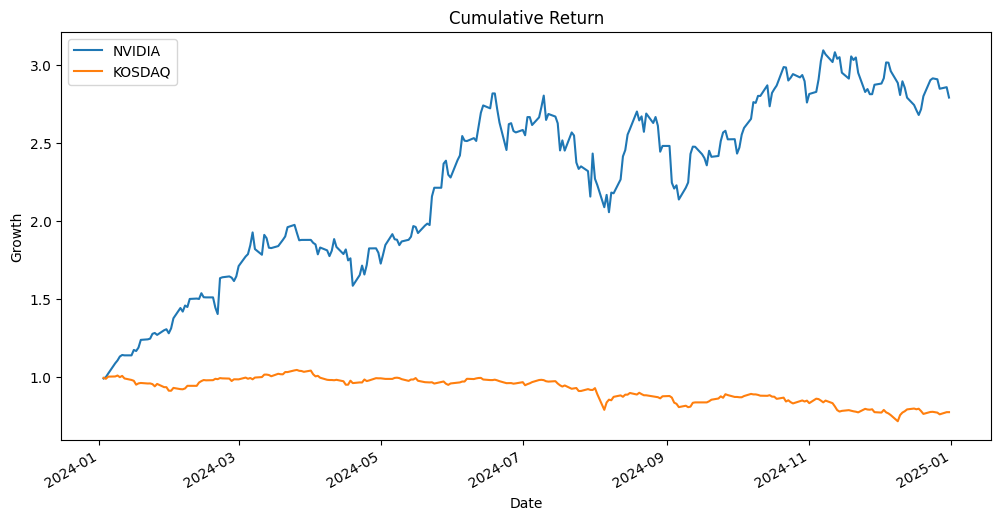


상관계수
          NVIDIA    KOSDAQ
NVIDIA  1.000000  0.132689
KOSDAQ  0.132689  1.000000


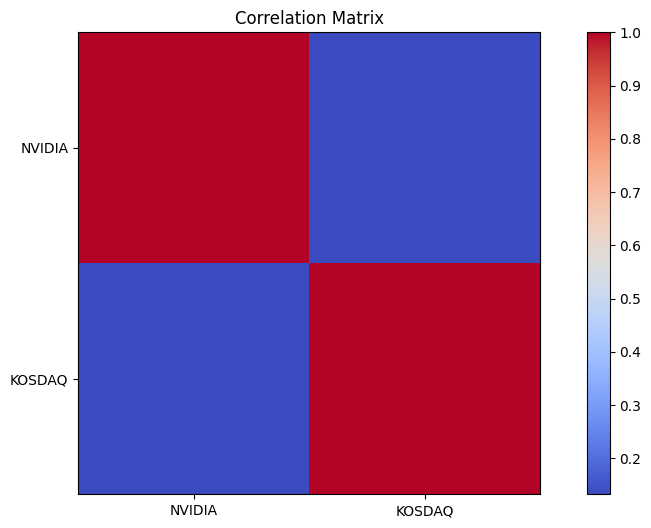

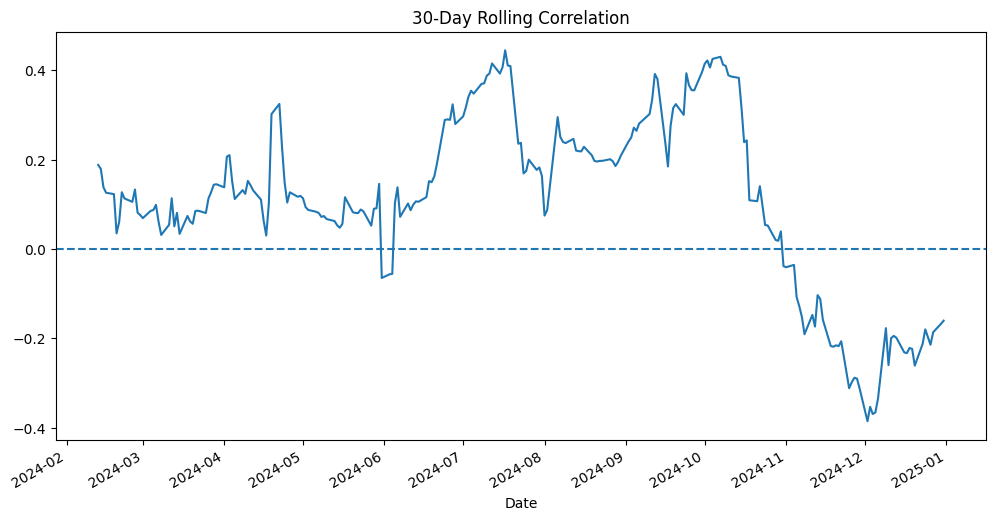


Beta: 0.2874
Alpha: 0.004745


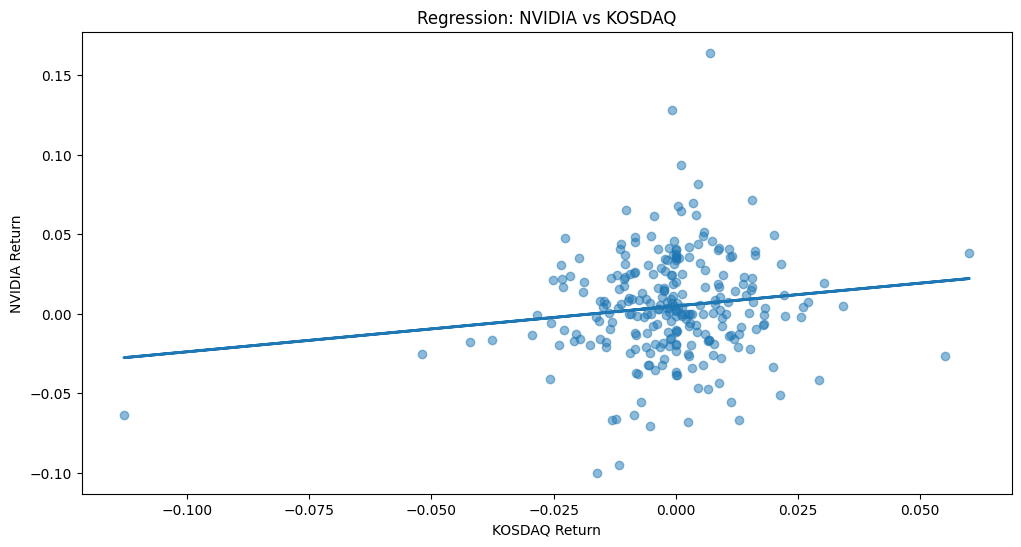


연율화 변동성
NVIDIA    0.517057
KOSDAQ    0.238716
dtype: float64

Sharpe Ratio
NVIDIA    2.130551
KOSDAQ   -1.061111
dtype: float64

MDD
NVIDIA: -27.05%
KOSDAQ : -31.56%

디커플링 발생 구간
Date
2024-02-13    0.187898
2024-02-14    0.179048
2024-02-15    0.137908
2024-02-16    0.125671
2024-02-19    0.122596
                ...   
2024-12-24   -0.180135
2024-12-26   -0.214564
2024-12-27   -0.186593
2024-12-30   -0.167734
2024-12-31   -0.160602
Length: 157, dtype: float64

===== 분석 요약 =====

1. 엔비디아와 코스닥의 상관관계:
   0.13

2. 엔비디아의 시장 민감도(Beta):
   0.29

3. 엔비디아 연율 변동성:
   51.71%

4. 엔비디아 Sharpe Ratio:
   2.13

5. 엔비디아 최대 낙폭(MDD):
   -27.05%



In [4]:
# =========================================================
# STEP 1. 라이브러리 설치 및 import
# =========================================================

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (12,6)

# =========================================================
# STEP 2. 데이터 수집
# =========================================================

# 엔비디아 / 코스닥
tickers = ["NVDA", "^KQ11"]

data = yf.download(
    tickers,
    start="2024-01-01",
    end="2025-01-01"
)["Close"]

data.columns = ["NVIDIA", "KOSDAQ"]

print(data.head())

# =========================================================
# STEP 3. 수익률 계산
# =========================================================

returns = data.pct_change().dropna()

print("\n일간 수익률")
print(returns.head())

# =========================================================
# STEP 4. 누적 수익률 시각화
# =========================================================

cum_returns = (1 + returns).cumprod()

cum_returns.plot(title="Cumulative Return")
plt.ylabel("Growth")
plt.show()

# =========================================================
# STEP 5. 상관관계 분석
# =========================================================

corr = returns.corr()

print("\n상관계수")
print(corr)

# Heatmap 없이 간단 시각화
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks([0,1], corr.columns)
plt.yticks([0,1], corr.columns)

plt.title("Correlation Matrix")
plt.show()

# =========================================================
# STEP 6. Rolling Correlation
# =========================================================

rolling_corr = returns["NVIDIA"].rolling(30).corr(
    returns["KOSDAQ"]
)

rolling_corr.plot(
    title="30-Day Rolling Correlation"
)

plt.axhline(0, linestyle='--')
plt.show()

# =========================================================
# STEP 7. 회귀분석 (Beta 계산)
# =========================================================

X = returns["KOSDAQ"].values.reshape(-1,1)
y = returns["NVIDIA"].values

model = LinearRegression()
model.fit(X, y)

beta = model.coef_[0]
alpha = model.intercept_

print(f"\nBeta: {beta:.4f}")
print(f"Alpha: {alpha:.6f}")

# 산점도 + 회귀선
plt.scatter(X, y, alpha=0.5)

plt.plot(
    X,
    model.predict(X),
    linewidth=2
)

plt.title("Regression: NVIDIA vs KOSDAQ")
plt.xlabel("KOSDAQ Return")
plt.ylabel("NVIDIA Return")

plt.show()

# =========================================================
# STEP 8. 변동성(Volatility)
# =========================================================

volatility = returns.std() * np.sqrt(252)

print("\n연율화 변동성")
print(volatility)

# =========================================================
# STEP 9. Sharpe Ratio
# =========================================================

risk_free_rate = 0.03

annual_return = returns.mean() * 252

sharpe_ratio = (
    (annual_return - risk_free_rate)
    / volatility
)

print("\nSharpe Ratio")
print(sharpe_ratio)

# =========================================================
# STEP 10. MDD(Max Drawdown)
# =========================================================

def calculate_mdd(series):

    cumulative = (1 + series).cumprod()

    peak = cumulative.cummax()

    drawdown = (
        cumulative - peak
    ) / peak

    return drawdown.min()

mdd_nvidia = calculate_mdd(returns["NVIDIA"])
mdd_kosdaq = calculate_mdd(returns["KOSDAQ"])

print("\nMDD")
print(f"NVIDIA: {mdd_nvidia:.2%}")
print(f"KOSDAQ : {mdd_kosdaq:.2%}")

# =========================================================
# STEP 11. 디커플링 분석
# =========================================================

# 상관관계가 급격히 낮아지는 구간 탐색

decoupling = rolling_corr[
    rolling_corr < 0.2
]

print("\n디커플링 발생 구간")
print(decoupling.dropna())

# =========================================================
# STEP 12. 결과 해석
# =========================================================

print("\n===== 분석 요약 =====")

print(f"""
1. 엔비디아와 코스닥의 상관관계:
   {corr.iloc[0,1]:.2f}

2. 엔비디아의 시장 민감도(Beta):
   {beta:.2f}

3. 엔비디아 연율 변동성:
   {volatility['NVIDIA']:.2%}

4. 엔비디아 Sharpe Ratio:
   {sharpe_ratio['NVIDIA']:.2f}

5. 엔비디아 최대 낙폭(MDD):
   {mdd_nvidia:.2%}
""")

기술주라고 같이 움직이지 않았다

삼성전자 vs 나스닥
상관관계: 0.14
Beta: 0.24

엔비디아 vs 코스닥
상관관계: 0.13
Beta: 0.29

둘 다 매우 낮다 -> 미국 기술주 상승이 한국 기술시장으로 거의 전달되지 않았다

엔비디아
변동성: 51.7%
Sharpe Ratio: 2.13

변동성은 매우 크지만
수익이 위험 대비 압도적으로 좋았다는 뜻 -> 시장이 높은 변동성을 감수할 만큼 강한 기대를 AI 산업에 부여

코스닥
변동성: 23.9%
Sharpe Ratio: -1.06

변동성은 존재하는데
보상이 없음 -> 위험을 감수했지만 성과가 따라오지 못한 시장

(이건 투자심리 위축,
성장주 프리미엄 약화,
유동성 감소 등을 시사)

# 2025 한 해

/tmp/ipykernel_5986/2772714190.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  2 of 2 completed
/tmp/ipykernel_5986/2772714190.py:37: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


                NVIDIA      KOSDAQ
Date                              
2025-01-02  138.264694  686.630005
2025-01-03  144.422684  705.760010
2025-01-06  149.381058  717.960022
2025-01-07  140.094101  718.289978
2025-01-08  140.064102  719.630005

일간 수익률
              NVIDIA    KOSDAQ
Date                          
2025-01-03  0.044538  0.027861
2025-01-06  0.034332  0.017286
2025-01-07 -0.062170  0.000460
2025-01-08 -0.000214  0.001866
2025-01-09  0.000000  0.005406


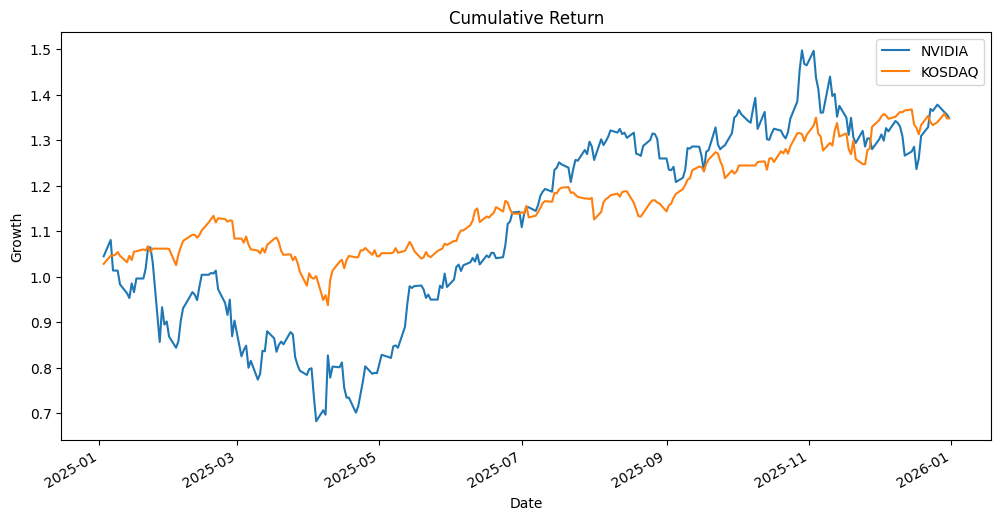


상관계수
          NVIDIA    KOSDAQ
NVIDIA  1.000000  0.074745
KOSDAQ  0.074745  1.000000


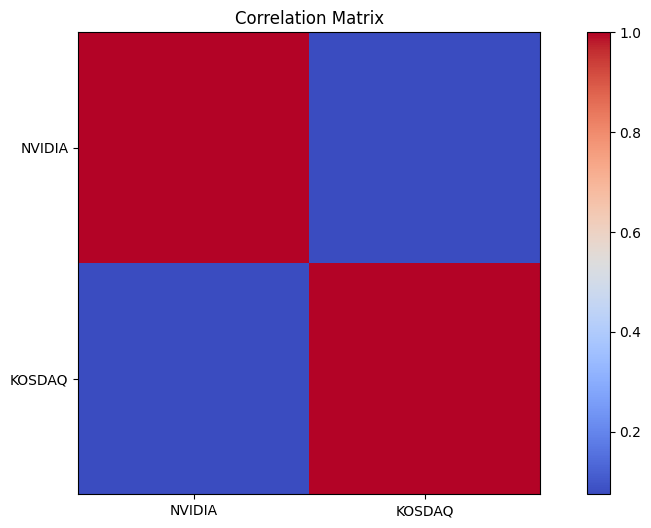

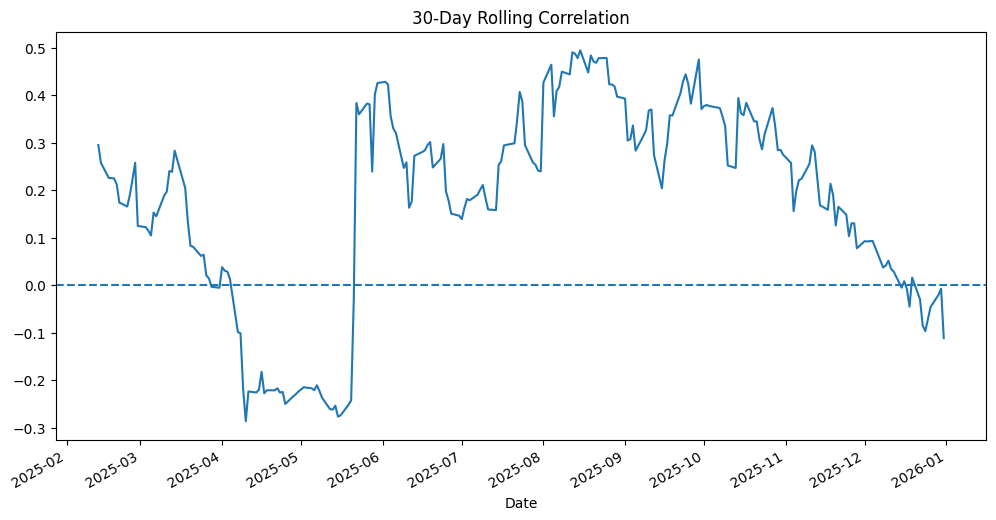


Beta: 0.1785
Alpha: 0.001411


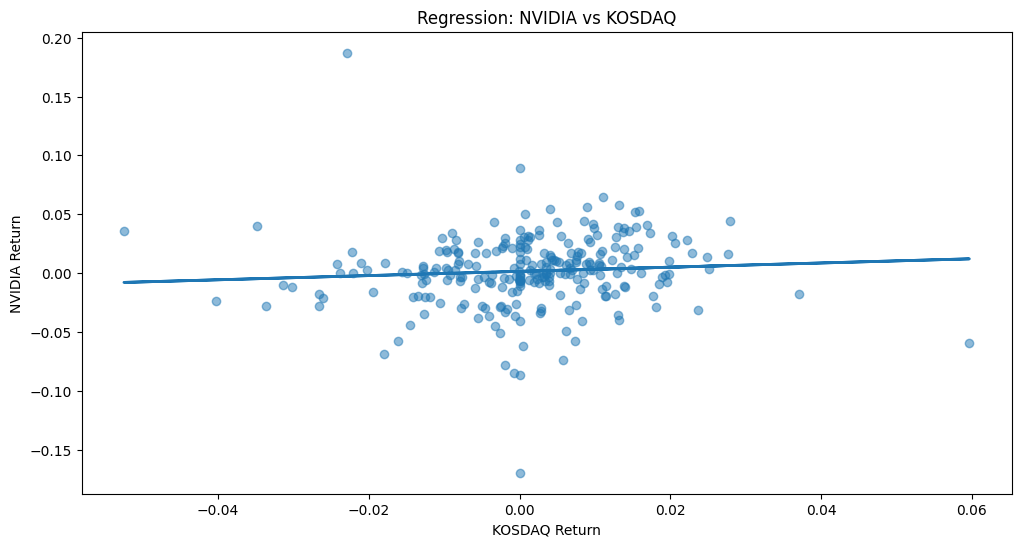


연율화 변동성
NVIDIA    0.487623
KOSDAQ    0.204189
dtype: float64

Sharpe Ratio
NVIDIA    0.782196
KOSDAQ    1.383691
dtype: float64

MDD
NVIDIA: -36.88%
KOSDAQ : -17.33%

디커플링 발생 구간
Date
2025-02-21    0.174141
2025-02-24    0.165847
2025-02-25    0.190876
2025-02-28    0.124949
2025-03-03    0.122351
                ...   
2025-12-24   -0.096760
2025-12-26   -0.045894
2025-12-29   -0.020368
2025-12-30   -0.007557
2025-12-31   -0.111366
Length: 105, dtype: float64

===== 분석 요약 =====

1. 엔비디아와 코스닥의 상관관계:
   0.07

2. 엔비디아의 시장 민감도(Beta):
   0.18

3. 엔비디아 연율 변동성:
   48.76%

4. 엔비디아 Sharpe Ratio:
   0.78

5. 엔비디아 최대 낙폭(MDD):
   -36.88%



In [3]:
# =========================================================
# STEP 1. 라이브러리 설치 및 import
# =========================================================

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (12,6)

# =========================================================
# STEP 2. 데이터 수집
# =========================================================

# 엔비디아 / 코스닥
tickers = ["NVDA", "^KQ11"]

data = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-01-01"
)["Close"]

data.columns = ["NVIDIA", "KOSDAQ"]

print(data.head())

# =========================================================
# STEP 3. 수익률 계산
# =========================================================

returns = data.pct_change().dropna()

print("\n일간 수익률")
print(returns.head())

# =========================================================
# STEP 4. 누적 수익률 시각화
# =========================================================

cum_returns = (1 + returns).cumprod()

cum_returns.plot(title="Cumulative Return")
plt.ylabel("Growth")
plt.show()

# =========================================================
# STEP 5. 상관관계 분석
# =========================================================

corr = returns.corr()

print("\n상관계수")
print(corr)

# Heatmap 없이 간단 시각화
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks([0,1], corr.columns)
plt.yticks([0,1], corr.columns)

plt.title("Correlation Matrix")
plt.show()

# =========================================================
# STEP 6. Rolling Correlation
# =========================================================

rolling_corr = returns["NVIDIA"].rolling(30).corr(
    returns["KOSDAQ"]
)

rolling_corr.plot(
    title="30-Day Rolling Correlation"
)

plt.axhline(0, linestyle='--')
plt.show()

# =========================================================
# STEP 7. 회귀분석 (Beta 계산)
# =========================================================

X = returns["KOSDAQ"].values.reshape(-1,1)
y = returns["NVIDIA"].values

model = LinearRegression()
model.fit(X, y)

beta = model.coef_[0]
alpha = model.intercept_

print(f"\nBeta: {beta:.4f}")
print(f"Alpha: {alpha:.6f}")

# 산점도 + 회귀선
plt.scatter(X, y, alpha=0.5)

plt.plot(
    X,
    model.predict(X),
    linewidth=2
)

plt.title("Regression: NVIDIA vs KOSDAQ")
plt.xlabel("KOSDAQ Return")
plt.ylabel("NVIDIA Return")

plt.show()

# =========================================================
# STEP 8. 변동성(Volatility)
# =========================================================

volatility = returns.std() * np.sqrt(252)

print("\n연율화 변동성")
print(volatility)

# =========================================================
# STEP 9. Sharpe Ratio
# =========================================================

risk_free_rate = 0.03

annual_return = returns.mean() * 252

sharpe_ratio = (
    (annual_return - risk_free_rate)
    / volatility
)

print("\nSharpe Ratio")
print(sharpe_ratio)

# =========================================================
# STEP 10. MDD(Max Drawdown)
# =========================================================

def calculate_mdd(series):

    cumulative = (1 + series).cumprod()

    peak = cumulative.cummax()

    drawdown = (
        cumulative - peak
    ) / peak

    return drawdown.min()

mdd_nvidia = calculate_mdd(returns["NVIDIA"])
mdd_kosdaq = calculate_mdd(returns["KOSDAQ"])

print("\nMDD")
print(f"NVIDIA: {mdd_nvidia:.2%}")
print(f"KOSDAQ : {mdd_kosdaq:.2%}")

# =========================================================
# STEP 11. 디커플링 분석
# =========================================================

# 상관관계가 급격히 낮아지는 구간 탐색

decoupling = rolling_corr[
    rolling_corr < 0.2
]

print("\n디커플링 발생 구간")
print(decoupling.dropna())

# =========================================================
# STEP 12. 결과 해석
# =========================================================

print("\n===== 분석 요약 =====")

print(f"""
1. 엔비디아와 코스닥의 상관관계:
   {corr.iloc[0,1]:.2f}

2. 엔비디아의 시장 민감도(Beta):
   {beta:.2f}

3. 엔비디아 연율 변동성:
   {volatility['NVIDIA']:.2%}

4. 엔비디아 Sharpe Ratio:
   {sharpe_ratio['NVIDIA']:.2f}

5. 엔비디아 최대 낙폭(MDD):
   {mdd_nvidia:.2%}
""")

비디아의 절대 영향력은 여전히 크지만, 코스닥과의 동조화는 오히려 더 약해졌다

특히 상관관계가 0.07까지 떨어졌다

엔비디아와 코스닥의 연결성이 사실상 거의 사라짐
상관관계: 0.07
Beta: 0.18

매우 낮은 수준의 동조화

AI가 좋다 → 한국 성장주도 좋다 의 논리가 통하지 않음

2024:

엔비디아 Sharpe: 2.13
코스닥 Sharpe: -1.06

→ 미국 AI 독주

2025:

엔비디아 Sharpe: 0.78
코스닥 Sharpe: 1.38

엔비디아
여전히 변동성 매우 큼
MDD도 -36.9%
하지만 위험 대비 성과는 둔화
AI 초과 기대가 일부 조정되기 시작한 상태

코스닥
변동성 낮아짐
Sharpe Ratio 개선
MDD도 상대적으로 안정적
코스닥은 투기적 성장시장보다는 안정적 회복 국면에 가까워졌을 가능성

고변동 AI 주도 시장 vs 안정 회복형 국내 시장

완전히 다른 구조

엔비디아
초고변동
대형 이벤트 민감
AI 기대감 반영
글로벌 자금 집중

코스닥
상대적으로 안정
낙폭 제한적
위험 대비 수익 개선

-> 두 시장의 투자 논리가 완전히 분리

디커플링 기간이 여전히 길다

105일 동안 디커플링 발생

rolling correlation이:

0 부근
음수 영역까지 반복함 -> 단기 잡음이 아니라
구조적 비동조화(structural decoupling)